Model trained in https://www.kaggle.com/hmendonca/efficientnetb4-ignite-amp-clr-aptos19

In [1]:
!ls ../input/*

../input/description.md		    ../input/test.zip
../input/sample_submission.csv	    ../input/train.csv
../input/sample_submission.csv.zip  ../input/train.csv.zip
../input/test.csv		    ../input/train_images.zip
../input/test.csv.zip		    ../input/train.zip
../input/test_images.zip

../input/aptos2019-blindness-detection:
aptos2019-blindness-detection  test.csv		test.zip       train_images.zip
description.md		       test.csv.zip	train.csv      train.zip
sample_submission.csv	       test_images	train.csv.zip
sample_submission.csv.zip      test_images.zip	train_images

../input/test_images:
001639a390f0.png  40e9b5630438.png  878e356c8fc9.png  ccea49708830.png
01b3aed3ed4c.png  437900a99871.png  87b671c6d4c5.png  cd29c88c9e36.png
0232dfea7547.png  437cbec4a3f8.png  894a37fc3738.png  cd48cfab4e44.png
025a169a0bb0.png  43fb6eda9b97.png  896ad584a841.png  cd563556cb57.png
0304bedad8fe.png  4464bb62bf20.png  898f0bc8acfa.png  cf1b9d26d38d.png
0369f3efe69b.png  44976c3b11a6.png  89d2a7403a06.png

In [2]:
target = '../input/efficientnet*/efficientNet_*.pth'
model_path = 'efficientNet_best.pth'
!md5sum {target}
!cp {target} {model_path}
!md5sum {model_path}

md5sum: '../input/efficientnet*/efficientNet_*.pth': No such file or directory
cp: cannot stat '../input/efficientnet*/efficientNet_*.pth': No such file or directory
md5sum: efficientNet_best.pth: No such file or directory


In [3]:
import torch
import torch.nn as nn

class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class Flatten(nn.Module):
    def forward(self, x):
        return x.reshape(x.shape[0], -1)

class SqueezeExcitation(nn.Module):
    
    def __init__(self, inplanes, se_planes):
        super(SqueezeExcitation, self).__init__()
        self.reduce_expand = nn.Sequential(
            nn.Conv2d(inplanes, se_planes, 
                      kernel_size=1, stride=1, padding=0, bias=True),
            Swish(),
            nn.Conv2d(se_planes, inplanes, 
                      kernel_size=1, stride=1, padding=0, bias=True),
            nn.Sigmoid()
        )

    def forward(self, x):
        x_se = torch.mean(x, dim=(-2, -1), keepdim=True)
        x_se = self.reduce_expand(x_se)
        return x_se * x
    
from torch.nn import functional as F

class MBConv(nn.Module):
    def __init__(self, inplanes, planes, kernel_size, stride, 
                 expand_rate=1.0, se_rate=0.25, 
                 drop_connect_rate=0.2):
        super(MBConv, self).__init__()

        expand_planes = int(inplanes * expand_rate)
        se_planes = max(1, int(inplanes * se_rate))

        self.expansion_conv = None        
        if expand_rate > 1.0:
            self.expansion_conv = nn.Sequential(
                nn.Conv2d(inplanes, expand_planes, 
                          kernel_size=1, stride=1, padding=0, bias=False),
                nn.BatchNorm2d(expand_planes, momentum=0.01, eps=1e-3),
                Swish()
            )
            inplanes = expand_planes

        self.depthwise_conv = nn.Sequential(
            nn.Conv2d(inplanes, expand_planes,
                      kernel_size=kernel_size, stride=stride, 
                      padding=kernel_size // 2, groups=expand_planes,
                      bias=False),
            nn.BatchNorm2d(expand_planes, momentum=0.01, eps=1e-3),
            Swish()
        )

        self.squeeze_excitation = SqueezeExcitation(expand_planes, se_planes)
        
        self.project_conv = nn.Sequential(
            nn.Conv2d(expand_planes, planes, 
                      kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(planes, momentum=0.01, eps=1e-3),
        )

        self.with_skip = stride == 1
        self.drop_connect_rate = torch.tensor(drop_connect_rate, requires_grad=False)
    
    def _drop_connect(self, x):        
        keep_prob = 1.0 - self.drop_connect_rate
        drop_mask = torch.rand(x.shape[0], 1, 1, 1) + keep_prob
        drop_mask = drop_mask.type_as(x)
        drop_mask.floor_()
        return drop_mask * x / keep_prob
        
    def forward(self, x):
        z = x
        if self.expansion_conv is not None:
            x = self.expansion_conv(x)

        x = self.depthwise_conv(x)
        x = self.squeeze_excitation(x)
        x = self.project_conv(x)
        
        # Add identity skip
        if x.shape == z.shape and self.with_skip:            
            if self.training and self.drop_connect_rate is not None:
                self._drop_connect(x)
            x += z
        return x

from collections import OrderedDict
import math


def init_weights(module):    
    if isinstance(module, nn.Conv2d):    
        nn.init.kaiming_normal_(module.weight, a=0, mode='fan_out')
    elif isinstance(module, nn.Linear):
        init_range = 1.0 / math.sqrt(module.weight.shape[1])
        nn.init.uniform_(module.weight, a=-init_range, b=init_range)
        
        
class EfficientNet(nn.Module):
        
    def _setup_repeats(self, num_repeats):
        return int(math.ceil(self.depth_coefficient * num_repeats))
    
    def _setup_channels(self, num_channels):
        num_channels *= self.width_coefficient
        new_num_channels = math.floor(num_channels / self.divisor + 0.5) * self.divisor
        new_num_channels = max(self.divisor, new_num_channels)
        if new_num_channels < 0.9 * num_channels:
            new_num_channels += self.divisor
        return new_num_channels

    def __init__(self, num_classes, 
                 width_coefficient=1.0,
                 depth_coefficient=1.0,
                 se_rate=0.25,
                 dropout_rate=0.2,
                 drop_connect_rate=0.2):
        super(EfficientNet, self).__init__()
        
        self.width_coefficient = width_coefficient
        self.depth_coefficient = depth_coefficient
        self.divisor = 8
                
        list_channels = [32, 16, 24, 40, 80, 112, 192, 320, 1280]
        list_channels = [self._setup_channels(c) for c in list_channels]
                
        list_num_repeats = [1, 2, 2, 3, 3, 4, 1]
        list_num_repeats = [self._setup_repeats(r) for r in list_num_repeats]        
        
        expand_rates = [1, 6, 6, 6, 6, 6, 6]
        strides = [1, 2, 2, 2, 1, 2, 1]
        kernel_sizes = [3, 3, 5, 3, 5, 5, 3]

        # Define stem:
        self.stem = nn.Sequential(
            nn.Conv2d(3, list_channels[0], kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(list_channels[0], momentum=0.01, eps=1e-3),
            Swish()
        )
        
        # Define MBConv blocks
        blocks = []
        counter = 0
        num_blocks = sum(list_num_repeats)
        for idx in range(7):
            
            num_channels = list_channels[idx]
            next_num_channels = list_channels[idx + 1]
            num_repeats = list_num_repeats[idx]
            expand_rate = expand_rates[idx]
            kernel_size = kernel_sizes[idx]
            stride = strides[idx]
            drop_rate = drop_connect_rate * counter / num_blocks
            
            name = "MBConv{}_{}".format(expand_rate, counter)
            blocks.append((
                name,
                MBConv(num_channels, next_num_channels, 
                       kernel_size=kernel_size, stride=stride, expand_rate=expand_rate, 
                       se_rate=se_rate, drop_connect_rate=drop_rate)
            ))
            counter += 1
            for i in range(1, num_repeats):                
                name = "MBConv{}_{}".format(expand_rate, counter)
                drop_rate = drop_connect_rate * counter / num_blocks                
                blocks.append((
                    name,
                    MBConv(next_num_channels, next_num_channels, 
                           kernel_size=kernel_size, stride=1, expand_rate=expand_rate, 
                           se_rate=se_rate, drop_connect_rate=drop_rate)                                    
                ))
                counter += 1
        
        self.blocks = nn.Sequential(OrderedDict(blocks))
        
        # Define head
        self.head = nn.Sequential(
            nn.Conv2d(list_channels[-2], list_channels[-1], 
                      kernel_size=1, bias=False),
            nn.BatchNorm2d(list_channels[-1], momentum=0.01, eps=1e-3),
            Swish(),
            nn.AdaptiveAvgPool2d(1),
            Flatten(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(list_channels[-1], num_classes)
        )

        self.apply(init_weights)
        
    def forward(self, x):
        f = self.stem(x)
        f = self.blocks(f)
        y = self.head(f)
        return y

In [4]:
image_size = 380
best_model = EfficientNet(num_classes=1, width_coefficient=1.4, depth_coefficient=1.8) ## B4
best_model.load_state_dict(torch.load(model_path))
best_model = best_model.cuda().eval()

FileNotFoundError: [Errno 2] No such file or directory: 'efficientNet_best.pth'

In [5]:
from torchvision.transforms import Compose, RandomCrop, Pad, RandomHorizontalFlip, Resize, RandomAffine
from torchvision.transforms import ToTensor, Normalize

from torch.utils.data import Subset
import torchvision.utils as vutils

import os
import pandas as pd
from sklearn.utils import shuffle

from PIL import Image

class ImageDataset(torch.utils.data.Dataset):

    def __init__(self, root, path_list, targets=None, transform=None, extension='.png'):
        super().__init__()
        self.root = root
        self.path_list = path_list
        self.targets = targets
        self.transform = transform
        self.extension = extension
        if targets is not None:
            assert len(self.path_list) == len(self.targets)
            self.targets = torch.LongTensor(targets)

    def __getitem__(self, index):
        """
        Args:
            index (int): Index
        Returns:
            tuple: (sample, target) where target is class_index of the target class.
        """
        path = self.path_list[index]
        sample = Image.open(os.path.join(self.root, path+self.extension))
        if self.transform is not None:
            sample = self.transform(sample)

        if self.targets is not None:
            return sample, self.targets[index]
        else:
            return sample, torch.LongTensor([])

    def __len__(self):
        return len(self.path_list)

from PIL.Image import BICUBIC

test_transform = Compose([
    Resize((image_size,image_size), BICUBIC),
    ToTensor(),
    Normalize(mean=[0.42, 0.22, 0.075], std=[0.27, 0.15, 0.081])
])

df_test = pd.read_csv('../input/aptos2019-blindness-detection/test.csv')
test_dataset = ImageDataset(root='../input/aptos2019-blindness-detection/test_images', path_list=df_test.id_code.values, transform=test_transform)

# len(test_dataset)

In [6]:
from torch.utils.data import DataLoader

batch_size = 16
num_workers = os.cpu_count()
print('num_workers:', num_workers)

test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=num_workers, 
                         shuffle=False, drop_last=False, pin_memory=True)

num_workers: 32


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [7]:
def tta(x):
    ''' simple 8 fold TTA '''
    pred = []
    for flip1 in range(2): # flip 1st dim
        if flip1: x = x.flip(1)
        for flip2 in range(2): # flip 2nd dim
            if flip2: x = x.flip(2)
            for trans in range(2): # transpose
                if trans: x = x.transpose(-1,-2)
                pred.append(best_model(x)[...,-1].unsqueeze(0))
    # concat and calc mean softmax for submission
    return torch.cat(pred).mean(dim=0)

In [8]:
from tqdm import tqdm_notebook as tqdm

In [9]:
preds = []
with torch.no_grad():
    for x,_ in tqdm(test_loader, total=int(len(test_loader))):     
        # Let's compute final prediction as a mean of predictions on x and flipped x and/or transposed
        x = x.cuda()
        pred = tta(x)
        preds += pred.cpu().squeeze().tolist()

/tmp/ipykernel_10/2448080335.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for x,_ in tqdm(test_loader, total=int(len(test_loader))):


  0%|          | 0/23 [00:00<?, ?it/s]

RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

In [10]:
import scipy as sp

class KappaOptimizer(nn.Module):
    def __init__(self, coef=[0.5, 1.5, 2.5, 3.5]):
        super().__init__()
        self.coef = coef
        # define score function:
        self.func = self.quad_kappa
    
    def predict(self, preds):
        return self._predict(self.coef, preds)

    @classmethod
    def _predict(cls, coef, preds):
        if type(preds).__name__ == 'Tensor':
            y_hat = preds.clone().view(-1)
        else:
            y_hat = torch.FloatTensor(preds).view(-1)

        for i,pred in enumerate(y_hat):
            if   pred < coef[0]: y_hat[i] = 0
            elif pred < coef[1]: y_hat[i] = 1
            elif pred < coef[2]: y_hat[i] = 2
            elif pred < coef[3]: y_hat[i] = 3
            else:                y_hat[i] = 4
        return y_hat.int()
    
    def quad_kappa(self, preds, y):
        return self._quad_kappa(self.coef, preds, y)

    @classmethod
    def _quad_kappa(cls, coef, preds, y):
        y_hat = cls._predict(coef, preds)
        return cohen_kappa_score(y, y_hat, weights='quadratic')

    def fit(self, preds, y):
        ''' maximize quad_kappa '''
        print('Early score:', self.quad_kappa(preds, y))
        neg_kappa = lambda coef: -self._quad_kappa(coef, preds, y)
        opt_res = sp.optimize.minimize(neg_kappa, x0=self.coef, method='nelder-mead',
                                       options={'maxiter':100, 'fatol':1e-20, 'xatol':1e-20})
        print(opt_res)
        self.coef = opt_res.x
        print('New score:', self.quad_kappa(preds, y))

    def forward(self, preds, y):
        ''' the pytorch loss function '''
        return torch.tensor(self.quad_kappa(preds, y))


In [11]:
kappa_opt = KappaOptimizer()
# # fit on validation set
# kappa_opt.fit(preds, targets)
opt_preds = kappa_opt.predict(preds).tolist()

In [12]:
import numpy as np
print(len(preds))

sub = pd.read_csv('../input/aptos2019-blindness-detection/sample_submission.csv')
sub['diagnosis'] = np.array(opt_preds, dtype=np.int32)
sub.to_csv('submission.csv', index=False)
sub.head()

0


ValueError: Length of values (0) does not match length of index (367)

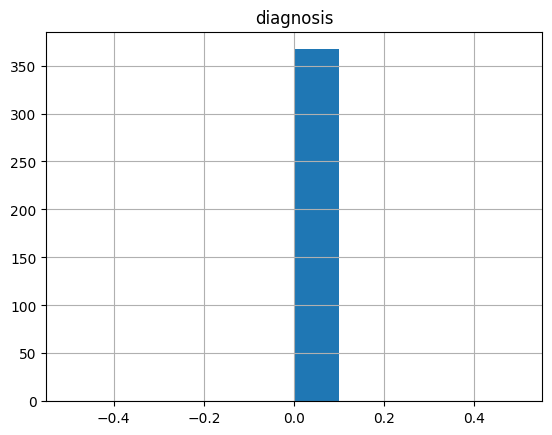

In [13]:
_ = sub.hist()

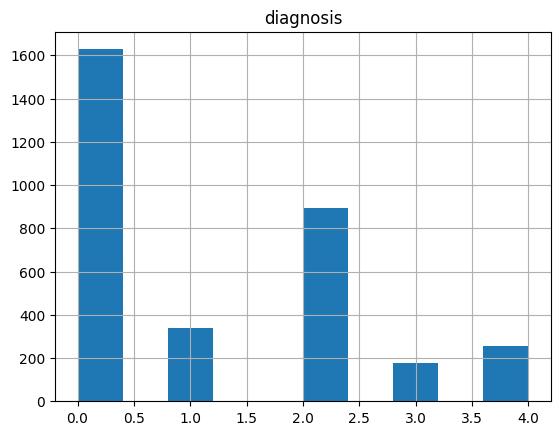

In [14]:
tr = pd.read_csv('../input/aptos2019-blindness-detection/train.csv')
_ = tr.hist()